### Employee Workforce Exploratory Data Analysis

#### Business Problem

Organizations collect employee data to understand workforce performance, salary distribution, employee satisfaction, and workforce trends.

The objective of this project is to analyze employee data, identify data quality issues, clean the dataset, explore important relationships, and generate meaningful business insights that can support better decision-making.



#### Project Objectives

- Understand the dataset structure.
- Identify data quality issues.
- Handle missing values.
- Remove duplicate records.
- Clean inconsistent data.
- Detect outliers.
- Perform univariate analysis.
- Perform bivariate analysis.
- Perform multivariate analysis.
- Generate business insights and recommendations.

In [2]:
#import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
# Import warnings library
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

In [3]:
#load dataset
df = pd.read_csv("../data/raw/employee_data.csv")

In [4]:
#display first five rows of dataset
df.head()

,Employee_ID,Name,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Joining_Date,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition,Email
0,1001,Farhan Ahmed,Male,38,Marketing,Karachi,4,Intermediate,Senior,111512,7.9,2014-09-18,True,Full-time,169,150,77,1.1,No,farhan.ahmed1001@company.com
1,1002,Farhan Chaudhry,Female,35,Design,Rawalpindi,8,Intermediate,Senior,NaN,6.7,2017-06-27,True,Part-time,183,7,11,2.5,No,farhan.chaudhry1002@company.com
2,1003,Hira Sheikh,Female,23,Design,Lhore,3,MPhil,Junior,56050,NaN,2015-07-24,True,Full-time,177,6,29,4.5,No,hira.sheikh1003@company.com
3,1004,Saad Butt,Female,NaN,Support,Islamabad,6,Master,Senior,118533,NaN,2017-11-02,True,Full-time,188,18,71,1.9,No,NaN
4,1005,Shahzaib Qureshi,Male,35,IT,Peshawar,10,MPhil,Junior,77905,9.3,2021-01-21,True,Full-time,190,30,18,NaN,No,shahzaib.qureshi1005@company.com


In [5]:
#display last five rows of dataset
df.tail()

,Employee_ID,Name,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Joining_Date,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition,Email
515,1095,Hassan Aslam,Male,29,Operations,Rawalpindi,1,Intermediate,Mid,69817,5.8,2019-01-22,Yes,Contract,206,19,10,2.0,No,hassan.aslam1095@company.com
516,1418,Hira Aslam,Male,47,HR,Lahore,11,Master,Junior,64101,6.8,2022-05-26,False,Full-time,143,10,18,4.1,No,hira.aslam1418@company.com
517,1442,Fatima Raza,Female,49,Marketing,Multan,18,Master,Junior,77004,6.0,2017-11-27,Yes,Contract,162,22,70,2.0,No,fatima.raza1442@company.com
518,1091,Farhan Malik,Female,45,IT,Rawalpindi,4,MPhil,Manager,206791,8.7,2017-02-01,False,Full-time,223,18,31,4.8,Yes,farhan.malik1091@company.com
519,1097,Bilal Butt,Male,57,it,Rawalpindi,20,Intermediate,Mid,141557,6.4,2020-10-10,False,Full-time,227,26,38,2.8,No,bilal.butt1097@company.com


In [6]:
#display dataset shape
df.shape

(520, 20)

In [7]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         520 non-null    int64  
 1   Name                520 non-null    object 
 2   Gender              520 non-null    object 
 3   Age                 485 non-null    object 
 4   Department          520 non-null    object 
 5   City                491 non-null    object 
 6   Experience_Years    520 non-null    int64  
 7   Education_Level     520 non-null    object 
 8   Job_Level           520 non-null    object 
 9   Salary              494 non-null    object 
 10  Performance_Score   499 non-null    float64
 11  Joining_Date        520 non-null    object 
 12  Is_Remote           520 non-null    object 
 13  Employment_Type     520 non-null    object 
 14  Monthly_Work_Hours  520 non-null    int64  
 15  Projects_Completed  520 non-null    int64  
 16  Training

In [8]:
#display column names
df.columns

Index(['Employee_ID', 'Name', 'Gender', 'Age', 'Department', 'City',
       'Experience_Years', 'Education_Level', 'Job_Level', 'Salary',
       'Performance_Score', 'Joining_Date', 'Is_Remote', 'Employment_Type',
       'Monthly_Work_Hours', 'Projects_Completed', 'Training_Hours',
       'Satisfaction_Score', 'Attrition', 'Email'],
      dtype='object')

In [9]:
#datatypes of columns
df.dtypes

Employee_ID             int64
Name                   object
Gender                 object
Age                    object
Department             object
City                   object
Experience_Years        int64
Education_Level        object
Job_Level              object
Salary                 object
Performance_Score     float64
Joining_Date           object
Is_Remote              object
Employment_Type        object
Monthly_Work_Hours      int64
Projects_Completed      int64
Training_Hours          int64
Satisfaction_Score    float64
Attrition              object
Email                  object
dtype: object

In [10]:
#display statistical summary of numerical columns
df.describe()

,Employee_ID,Experience_Years,Performance_Score,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score
count,520.000000,520.000000,499.000000,520.000000,520.000000,520.000000,502.000000
mean,1249.225000,10.519231,7.443687,184.725000,19.759615,40.278846,3.020518
std,144.110872,7.034433,1.483610,25.634893,22.040554,23.873001,1.167130
min,1001.000000,0.000000,5.000000,140.000000,1.000000,0.000000,1.000000
25%,1122.750000,4.000000,6.100000,162.750000,9.000000,19.000000,2.000000
50%,1246.500000,10.000000,7.400000,185.500000,19.000000,40.000000,3.100000
75%,1374.000000,16.000000,8.700000,206.250000,28.000000,62.000000,4.000000
max,1500.000000,25.000000,9.900000,230.000000,300.000000,80.000000,5.000000


#### Initial Observation

After loading the dataset:

- Successfully loaded the employee dataset.
- Verified the dataset dimensions.
- Reviewed column names and data types.
- Generated statistical summary.
- Ready for detailed data quality assessment.

### Data Quality Assessment

#### Objective

The objective of this section is to evaluate the quality of the dataset before cleaning and analysis.

We will check:

- Missing values
- Duplicate records
- Data types
- Unique values
- Invalid categories
- Memory usage

In [11]:
#chcking missing values
df.isnull().sum()

Employee_ID            0
Name                   0
Gender                 0
Age                   35
Department             0
City                  29
Experience_Years       0
Education_Level        0
Job_Level              0
Salary                26
Performance_Score     21
Joining_Date           0
Is_Remote              0
Employment_Type        0
Monthly_Work_Hours     0
Projects_Completed     0
Training_Hours         0
Satisfaction_Score    18
Attrition              0
Email                 17
dtype: int64

In [12]:
#calculate missing values percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Age                   6.730769
City                  5.576923
Salary                5.000000
Performance_Score     4.038462
Satisfaction_Score    3.461538
Email                 3.269231
Employee_ID           0.000000
Name                  0.000000
Gender                0.000000
Experience_Years      0.000000
Education_Level       0.000000
Department            0.000000
Joining_Date          0.000000
Job_Level             0.000000
Is_Remote             0.000000
Employment_Type       0.000000
Projects_Completed    0.000000
Monthly_Work_Hours    0.000000
Training_Hours        0.000000
Attrition             0.000000
dtype: float64

#### Observation

Identify which columns contain missing values and determine whether they require cleaning.

In [13]:
#chcking for duplicate records
df.duplicated().sum()

np.int64(20)

In [14]:
#display duplicate rows
df[df.duplicated()]

,Employee_ID,Name,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Joining_Date,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition,Email
500,1203,Taha Siddiqui,Male,43,Operations,karachi,5,Intermediate,Mid,88875,6.6,2014-01-23,True,Full-time,154,32,19,4.8,No,NaN
501,1080,Maria Iqbal,Male,53,IT,Multan,10,Bachelor,Mid,88466,5.9,2017-09-18,False,Full-time,186,16,56,3.4,No,NaN
502,1229,Laiba Malik,Female,31,IT,Islamabad,7,Bachelor,Senior,133074,6.4,2022-01-23,True,Full-time,182,31,59,2.8,No,laiba.malik1229@company.com
503,1119,Abdullah Khan,Male,34,HR,Lahore,14,Intermediate,Mid,108059,6.2,2014-12-29,False,Full-time,209,14,7,1.6,No,abdullah.khan1119@company.com
504,1374,Hamza Tariq,Female,31,Sales,Islamabad,11,Bachelor,Mid,102000,9.1,2026-01-07,True,Full-time,146,20,73,2.6,No,hamza.tariq1374@company.com
505,1372,Anam Sheikh,Male,42,Operations,Lahore,13,Master,Manager,227869,5.3,2019-06-24,True,Full-time,179,6,8,4.5,Yes,anam.sheikh1372@company.com
506,1223,Farhan Qureshi,Male,48,HR,lahore,17,MPhil,Senior,135137,5.1,2021-06-10,True,Full-time,146,12,32,3.2,No,farhan.qureshi1223@company.com
507,1189,Danish Qureshi,Male,25,Sales,Multan,5,MPhil,Junior,69999,5.1,2018-04-29,True,Contract,171,3,58,1.2,No,danish.qureshi1189@company.com
508,1076,Farhan Iqbal,Male,53,Operations,Faisalabad,18,Intermediate,Mid,142976,8.2,2021-03-18,False,Full-time,147,29,13,4.2,No,farhan.iqbal1076@company.com
509,1462,Taha Malik,Female,56,Marketing,Islambad,6,MPhil,Manager,201897,6.0,2021-12-31,False,Full-time,191,21,1,2.6,No,taha.malik1462@company.com


#### Observation

Review duplicate records before deciding whether they should be removed.

In [15]:
#chcking datatypes
df.dtypes

Employee_ID             int64
Name                   object
Gender                 object
Age                    object
Department             object
City                   object
Experience_Years        int64
Education_Level        object
Job_Level              object
Salary                 object
Performance_Score     float64
Joining_Date           object
Is_Remote              object
Employment_Type        object
Monthly_Work_Hours      int64
Projects_Completed      int64
Training_Hours          int64
Satisfaction_Score    float64
Attrition              object
Email                  object
dtype: object

In [16]:
# Display only object columns
df.select_dtypes(include="object").columns

Index(['Name', 'Gender', 'Age', 'Department', 'City', 'Education_Level',
       'Job_Level', 'Salary', 'Joining_Date', 'Is_Remote', 'Employment_Type',
       'Attrition', 'Email'],
      dtype='object')

In [17]:
# Display numerical columns
df.select_dtypes(include=["int64", "float64"]).columns


Index(['Employee_ID', 'Experience_Years', 'Performance_Score',
       'Monthly_Work_Hours', 'Projects_Completed', 'Training_Hours',
       'Satisfaction_Score'],
      dtype='object')

#### Observation

Verify whether every column has the correct data type.

In [18]:
# Count unique values in each column
df.nunique()

Employee_ID           500
Name                  314
Gender                  2
Age                    44
Department             15
City                   15
Experience_Years       26
Education_Level         4
Job_Level               5
Salary                465
Performance_Score      50
Joining_Date          474
Is_Remote              10
Employment_Type         3
Monthly_Work_Hours     91
Projects_Completed     38
Training_Hours         81
Satisfaction_Score     41
Attrition               2
Email                 475
dtype: int64

In [19]:
# Display unique department names
df["Department"].unique()

array(['Marketing', 'Design', 'Support', 'IT', 'Operations', 'HR',
       'Finance', ' it ', 'Sales', 'HR ', ' Sales', 'Finanace',
       'marketing', 'hr', 'support '], dtype=object)

In [20]:
# Display unique city names
df["City"].unique()

array(['Karachi', 'Rawalpindi', 'Lhore', 'Islamabad', 'Peshawar',
       'Multan', 'Lahore', 'Karach', 'Islambad', 'Faisalabad', nan,
       ' Multan ', 'ISLAMABAD', 'lahore', 'karachi', 'LAHORE'],
      dtype=object)

In [21]:
# Display unique remote work values
df["Is_Remote"].unique()

array(['True', ' false ', 'False', '0', 'FALSE', 'No', 'Yes', '1',
       ' true ', 'TRUE'], dtype=object)

#### Observation

Look for inconsistent spellings, extra spaces, and unexpected values.

In [22]:
# Display memory usage
df.memory_usage(deep=True)

Index                   132
Employee_ID            4160
Name                  35646
Gender                32280
Age                   29789
Department            32750
City                  32817
Experience_Years       4160
Education_Level       33676
Job_Level             32202
Salary                31781
Performance_Score      4160
Joining_Date          34846
Is_Remote             31933
Employment_Type       34234
Monthly_Work_Hours     4160
Projects_Completed     4160
Training_Hours         4160
Satisfaction_Score     4160
Attrition             30779
Email                 42768
dtype: int64

In [23]:
# Total memory usage in MB
memory = df.memory_usage(deep=True).sum() / 1024**2

print(f"Total Memory Usage: {memory:.2f} MB")

Total Memory Usage: 0.44 MB


#### Summary

This assessment identified:

- Missing values
- Duplicate records
- Incorrect categories
- Data type issues
- Dataset size
- Memory usage

The next step is Data Cleaning.

In [24]:
# Create a data quality report
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100,
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Missing Percentage,Unique Values
Employee_ID,int64,0,0.000000,500
Name,object,0,0.000000,314
Gender,object,0,0.000000,2
Age,object,35,6.730769,44
Department,object,0,0.000000,15
City,object,29,5.576923,15
Experience_Years,int64,0,0.000000,26
Education_Level,object,0,0.000000,4
Job_Level,object,0,0.000000,5
Salary,object,26,5.000000,465


### Data Cleaning

#### Objective

The goal of this section is to clean the dataset and make it suitable for analysis.

The following tasks will be performed:

- Handle missing values
- Remove duplicate records
- Clean text columns
- Standardize categorical values
- Convert data types
- Validate email addresses
- Handle invalid dates
- Save the cleaned dataset

In [25]:
#creating duplicate of dataset
clean_df = df.copy()

In [26]:
# Fill missing Age values using the median
clean_df["Age"] = pd.to_numeric(clean_df["Age"], errors="coerce")
clean_df["Age"] = clean_df["Age"].fillna(clean_df["Age"].median())

In [27]:
# Fill missing Salary values using the median
clean_df["Salary"] = pd.to_numeric(clean_df["Salary"], errors="coerce")
clean_df["Salary"] = clean_df["Salary"].fillna(clean_df["Salary"].median())

In [28]:
# Fill missing Performance Score using the mean
clean_df["Performance_Score"] = pd.to_numeric(
    clean_df["Performance_Score"],
    errors="coerce"
)

clean_df["Performance_Score"] = clean_df["Performance_Score"].fillna(
    clean_df["Performance_Score"].mean()
)

In [29]:
# Fill missing City values using the mode
clean_df["City"] = clean_df["City"].fillna(
    clean_df["City"].mode()[0]
)

In [30]:
# Fill missing Email values
clean_df["Email"] = clean_df["Email"].fillna("unknown@company.com")

In [31]:
# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

print(clean_df.shape)

(500, 20)


In [32]:
# Remove extra spaces from all object columns
text_columns = clean_df.select_dtypes(include="object").columns

for column in text_columns:
    clean_df[column] = clean_df[column].str.strip()

In [33]:
# Standardize city names
clean_df["City"] = clean_df["City"].replace({
    "lahore": "Lahore",
    "LAHORE": "Lahore",
    "Lhore": "Lahore",
    "Karach": "Karachi",
    "karachi": "Karachi",
    "ISLAMABAD": "Islamabad",
    "Islambad": "Islamabad"
})

In [34]:
# Standardize department names
clean_df["Department"] = clean_df["Department"].replace({
    "it": "IT",
    "IT": "IT",
    "IT ": "IT",
    "hr": "HR",
    "HR ": "HR",
    "marketing": "Marketing",
    " Sales": "Sales",
    "support": "Support",
    "support ": "Support",
    "Finanace": "Finance"
})

In [35]:
# Standardize remote work values
clean_df["Is_Remote"] = clean_df["Is_Remote"].replace({
    "TRUE": True,
    "FALSE": False,
    "Yes": True,
    "No": False,
    "1": True,
    "0": False,
    "true": True,
    "false": False
})

In [36]:
# Convert Joining_Date to datetime
clean_df["Joining_Date"] = pd.to_datetime(
    clean_df["Joining_Date"],
    errors="coerce"
)

In [37]:
# Keep only valid email addresses
email_pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'

valid_email = clean_df["Email"].str.match(email_pattern)

clean_df.loc[~valid_email, "Email"] = "unknown@company.com"

In [38]:
# Check missing values after cleaning
clean_df.isnull().sum()

Employee_ID            0
Name                   0
Gender                 0
Age                    0
Department             0
City                   0
Experience_Years       0
Education_Level        0
Job_Level              0
Salary                 0
Performance_Score      0
Joining_Date          12
Is_Remote              0
Employment_Type        0
Monthly_Work_Hours     0
Projects_Completed     0
Training_Hours         0
Satisfaction_Score    18
Attrition              0
Email                  0
dtype: int64

In [39]:
# Check data types
clean_df.dtypes

Employee_ID                    int64
Name                          object
Gender                        object
Age                          float64
Department                    object
City                          object
Experience_Years               int64
Education_Level               object
Job_Level                     object
Salary                       float64
Performance_Score            float64
Joining_Date          datetime64[ns]
Is_Remote                     object
Employment_Type               object
Monthly_Work_Hours             int64
Projects_Completed             int64
Training_Hours                 int64
Satisfaction_Score           float64
Attrition                     object
Email                         object
dtype: object

In [40]:
# Display cleaned dataset
clean_df.head()

,Employee_ID,Name,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Joining_Date,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition,Email
0,1001,Farhan Ahmed,Male,38.0,Marketing,Karachi,4,Intermediate,Senior,111512.0,7.900000,2014-09-18,True,Full-time,169,150,77,1.1,No,farhan.ahmed1001@company.com
1,1002,Farhan Chaudhry,Female,35.0,Design,Rawalpindi,8,Intermediate,Senior,111512.0,6.700000,2017-06-27,True,Part-time,183,7,11,2.5,No,farhan.chaudhry1002@company.com
2,1003,Hira Sheikh,Female,23.0,Design,Lahore,3,MPhil,Junior,56050.0,7.443687,2015-07-24,True,Full-time,177,6,29,4.5,No,hira.sheikh1003@company.com
3,1004,Saad Butt,Female,42.0,Support,Islamabad,6,Master,Senior,118533.0,7.443687,2017-11-02,True,Full-time,188,18,71,1.9,No,unknown@company.com
4,1005,Shahzaib Qureshi,Male,35.0,IT,Peshawar,10,MPhil,Junior,77905.0,9.300000,2021-01-21,True,Full-time,190,30,18,NaN,No,shahzaib.qureshi1005@company.com


In [41]:
# Save cleaned dataset
clean_df.to_csv(
    "../data/cleaned/employee_data_cleaned.csv",
    index=False
)

### Business Insight

After cleaning:

- Missing values were handled.
- Duplicate records were removed.
- City and department names were standardized.
- Invalid dates were converted to missing values.
- Invalid email addresses were replaced.
- The cleaned dataset is now ready for exploratory analysis.

### Exploratory Data Analysis

#### Univariate Analysis

#### Objective

Analyze each feature individually to understand its distribution, central tendency, spread, and frequency.

In [42]:
# Display statistical summary
clean_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Employee_ID,500.0,1250.5,1001.0,1125.75,1250.5,1375.25,1500.0,144.481833
Age,500.0,40.776,5.0,33.0,42.0,49.0,120.0,10.813866
Experience_Years,500.0,10.56,0.0,4.0,10.0,16.0,25.0,7.067269
Salary,500.0,131968.044,39221.0,84150.25,111512.0,151056.75,1250000.0,111544.162598
Performance_Score,500.0,7.462147,5.0,6.2,7.443687,8.7,9.9,1.452858
Joining_Date,488,2020-05-03 14:21:38.360655616,2014-01-02 00:00:00,2017-06-18 00:00:00,2020-05-21 00:00:00,2023-03-09 06:00:00,2026-07-31 00:00:00,NaN
Monthly_Work_Hours,500.0,184.886,140.0,163.0,186.0,206.25,230.0,25.580103
Projects_Completed,500.0,19.742,1.0,9.0,19.0,28.0,300.0,22.400156
Training_Hours,500.0,40.42,0.0,19.75,41.0,62.0,80.0,23.889852
Satisfaction_Score,482.0,3.024896,1.0,2.0,3.1,4.0,5.0,1.167261


### Business Insight

The statistical summary provides an overview of the numerical features, including average values, spread, and possible extreme values.

In [43]:
# Display categorical column summary
clean_df.describe(include="object").T

,count,unique,top,freq
Name,500,302,Saad Chaudhry,6
Gender,500,2,Female,273
Department,500,8,IT,73
City,500,7,Multan,107
Education_Level,500,4,Bachelor,128
Job_Level,500,5,Mid,156
Is_Remote,500,4,True,242
Employment_Type,500,3,Full-time,396
Attrition,500,2,No,405
Email,500,471,unknown@company.com,30


### Business Insight

Categorical summary helps identify the most frequent category and the number of unique values.

In [44]:
# Separate numerical columns
numerical_columns = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns

numerical_columns

Index(['Employee_ID', 'Age', 'Experience_Years', 'Salary', 'Performance_Score',
       'Monthly_Work_Hours', 'Projects_Completed', 'Training_Hours',
       'Satisfaction_Score'],
      dtype='object')

In [45]:
# Separate categorical columns
categorical_columns = clean_df.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['Name', 'Gender', 'Department', 'City', 'Education_Level', 'Job_Level',
       'Is_Remote', 'Employment_Type', 'Attrition', 'Email'],
      dtype='object')

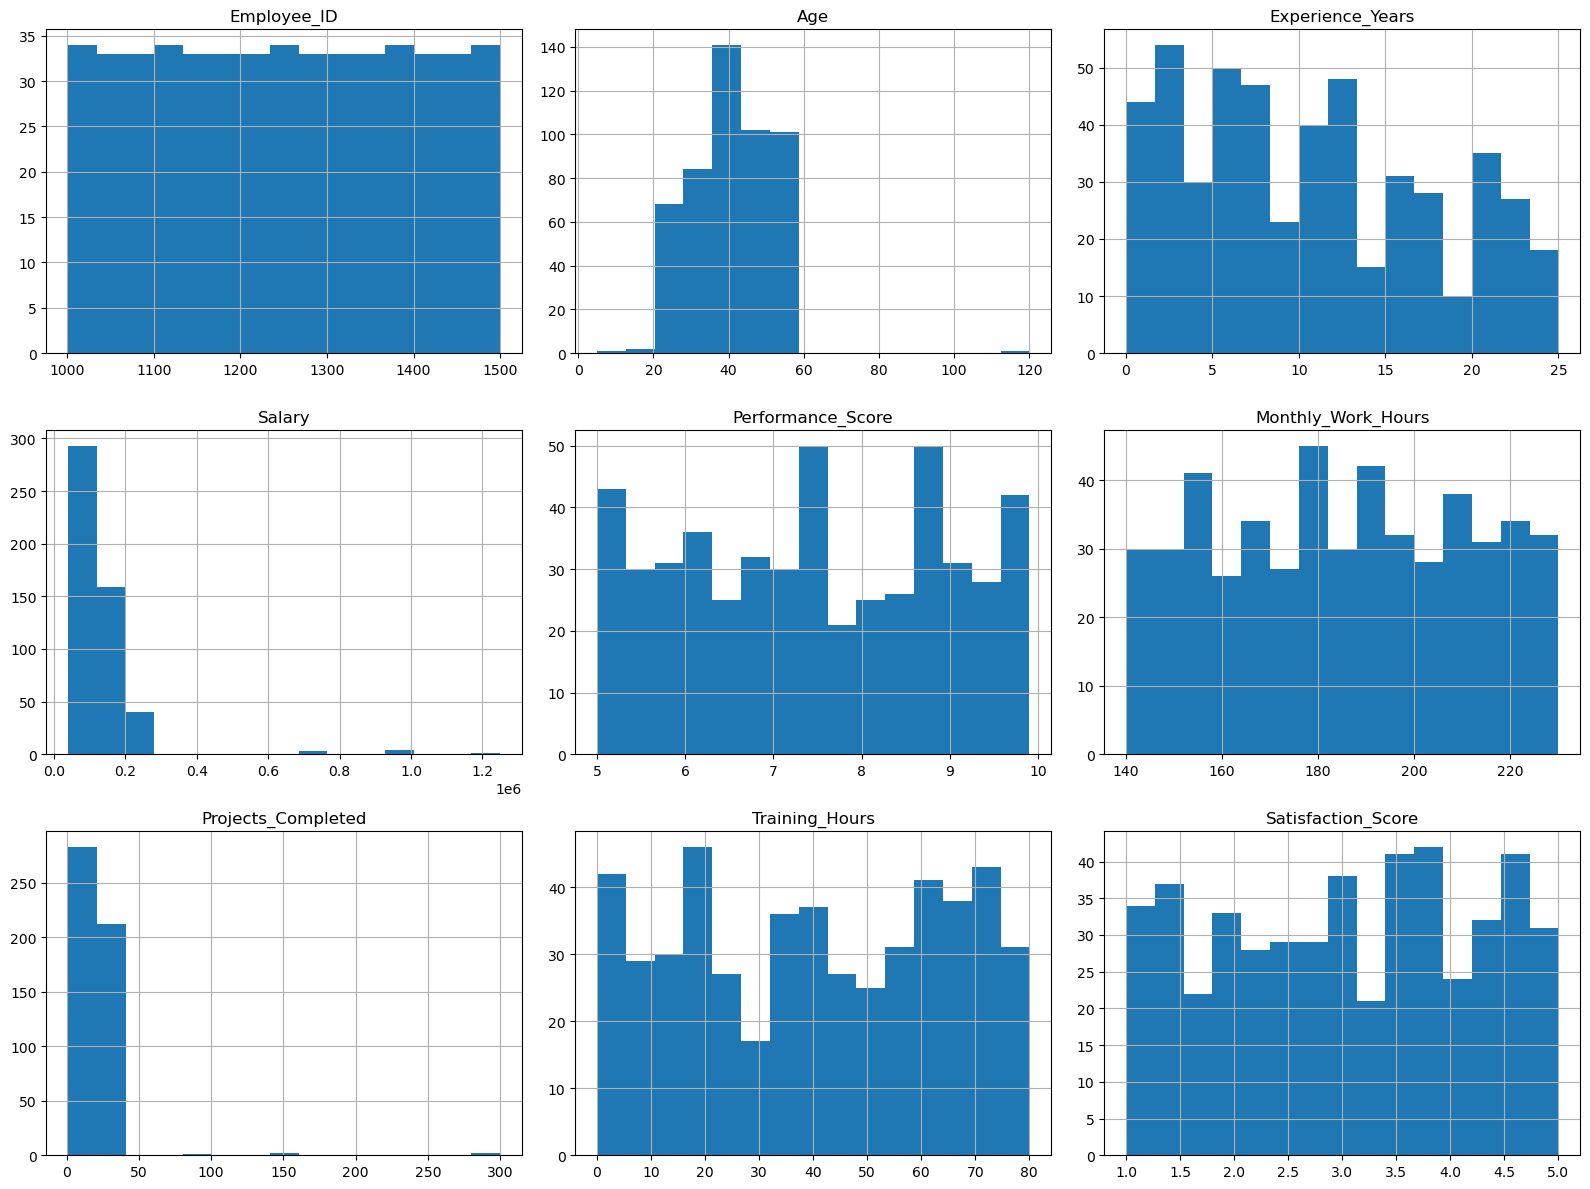

In [46]:
# Plot histogram for all numerical columns

clean_df[numerical_columns].hist(
    figsize=(16,12),
    bins=15
)

plt.tight_layout()

plt.show()

### Business Insight

Histograms help identify the distribution of numerical variables, including skewness, concentration of values, and potential outliers.

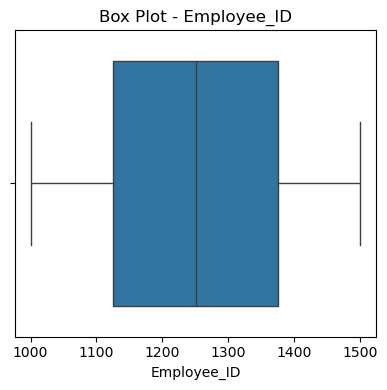

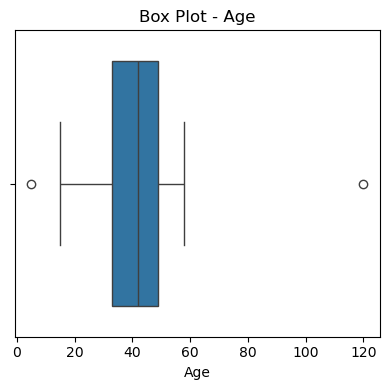

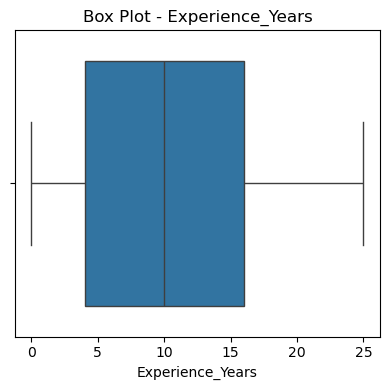

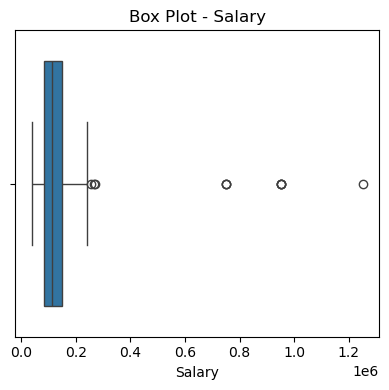

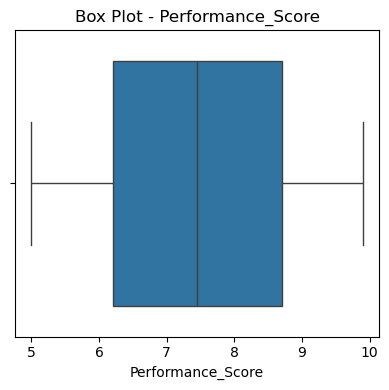

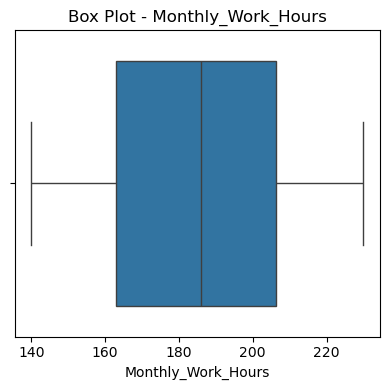

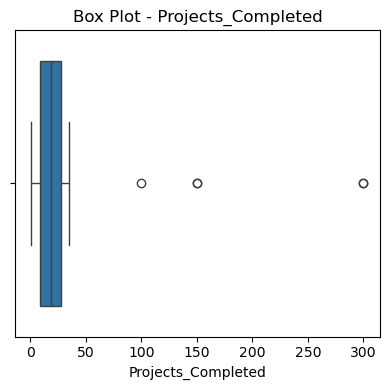

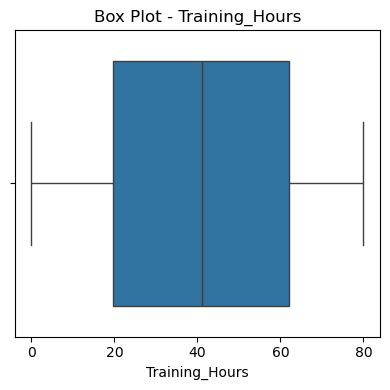

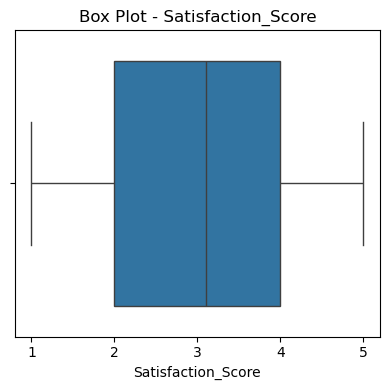

In [47]:
# Box plots for numerical columns

for column in numerical_columns:

    plt.figure(figsize=(4,4))

    sns.boxplot(x=clean_df[column])

    plt.title(f"Box Plot - {column}")

    plt.tight_layout()

    plt.show()

### Business Insight

Box plots help identify the spread of the data and detect potential outliers in each numerical feature.

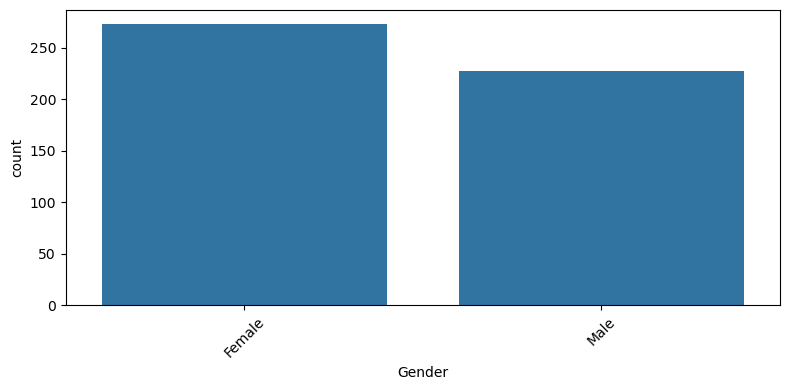

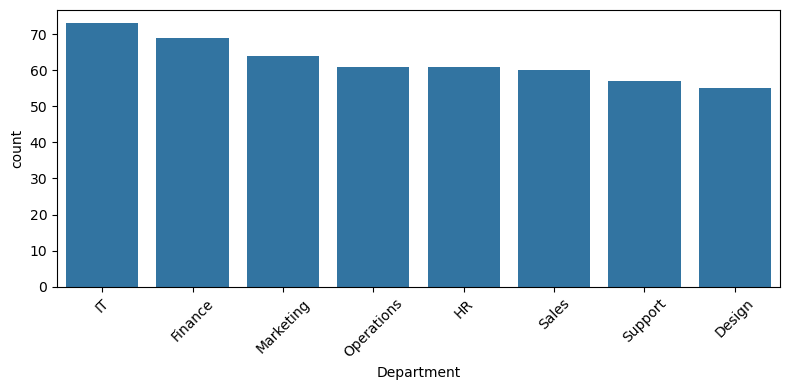

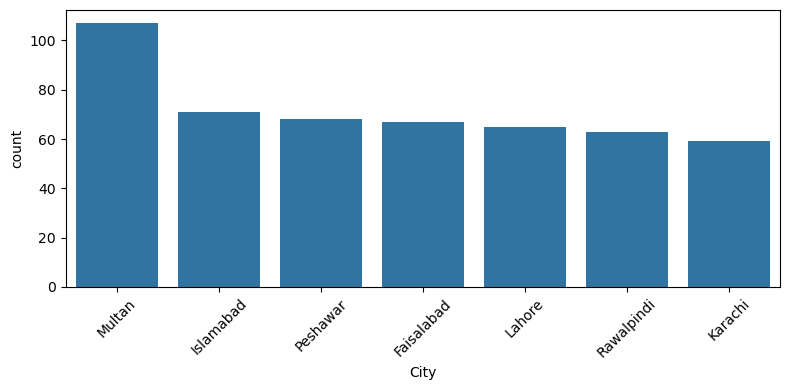

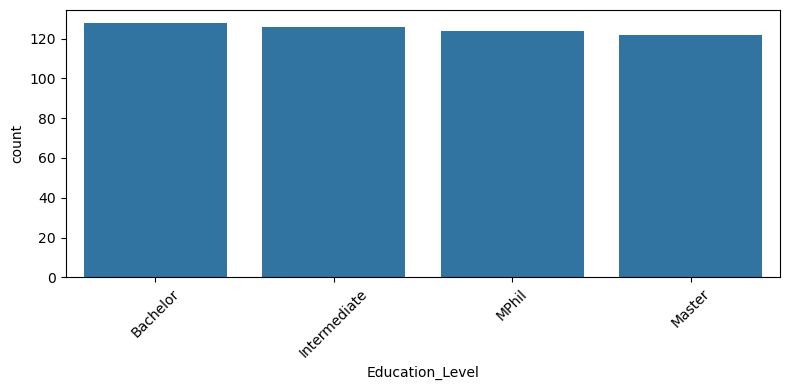

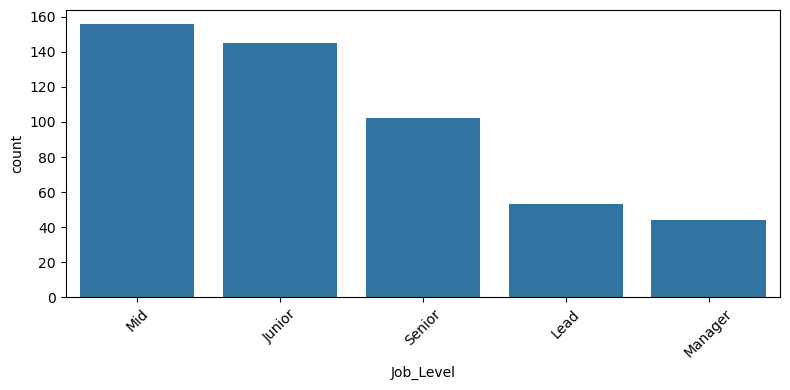

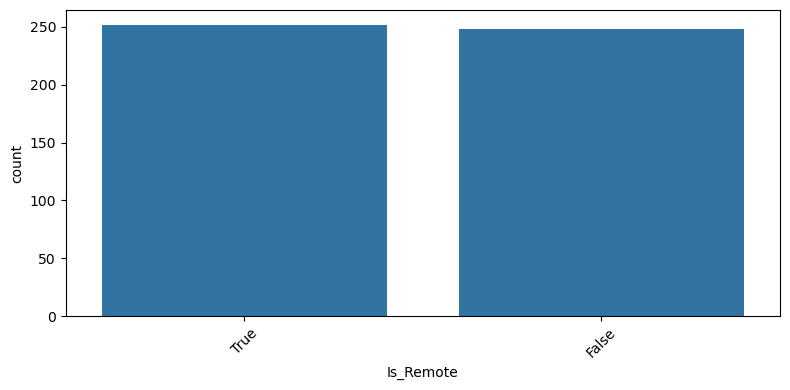

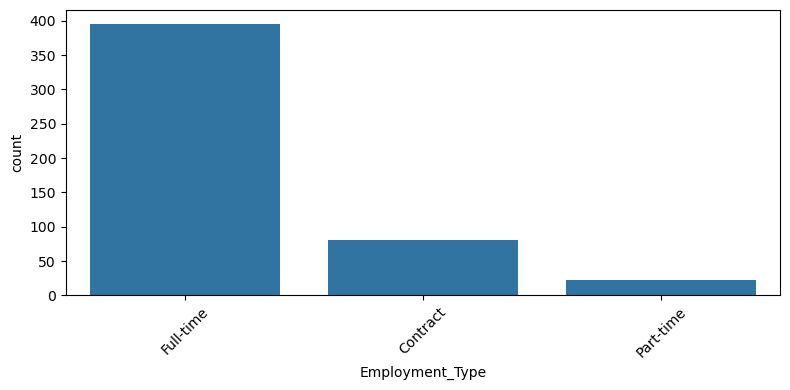

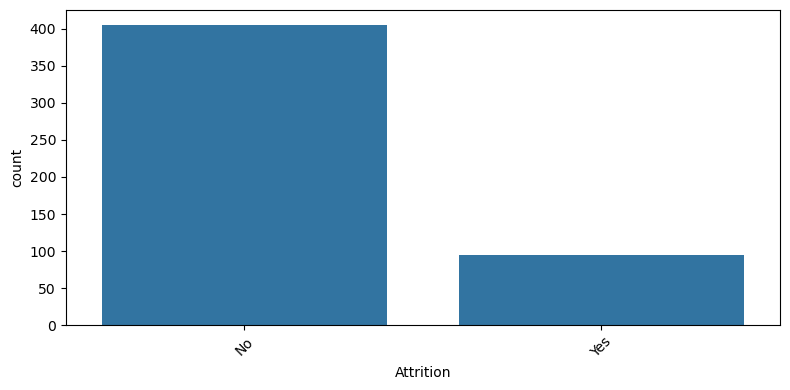

In [73]:
# Plot count plots for categorical columns
skip_columns = ["Name", "Employee_ID", "Email"]

for column in categorical_columns:
    if column in skip_columns:
        continue

    plt.figure(figsize=(8,4))
    sns.countplot(
        data=clean_df,
        x=column,
        order=clean_df[column].value_counts().index
    )
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Business Insight

Count plots reveal the frequency of each category and help identify dominant or underrepresented groups.

In [49]:
# Display frequency tables

for column in categorical_columns:

    print("=" * 60)

    print(column)

    print(clean_df[column].value_counts())

    print()

Name
Name
Saad Chaudhry    6
Maria Butt       5
Anam Sheikh      5
Talha Noor       4
Ahmed Qureshi    4
                ..
Danish Butt      1
Hira Siddiqui    1
Noor Siddiqui    1
Hamza Qureshi    1
Sara Raza        1
Name: count, Length: 302, dtype: int64

Gender
Gender
Female    273
Male      227
Name: count, dtype: int64

Department
Department
IT            73
Finance       69
Marketing     64
Operations    61
HR            61
Sales         60
Support       57
Design        55
Name: count, dtype: int64

City
City
Multan        107
Islamabad      71
Peshawar       68
Faisalabad     67
Lahore         65
Rawalpindi     63
Karachi        59
Name: count, dtype: int64

Education_Level
Education_Level
Bachelor        128
Intermediate    126
MPhil           124
Master          122
Name: count, dtype: int64

Job_Level
Job_Level
Mid        156
Junior     145
Senior     102
Lead        53
Manager     44
Name: count, dtype: int64

Is_Remote
Is_Remote
True     242
False    230
False     18
True

In [50]:
# Calculate detailed statistics

statistics = pd.DataFrame({

    "Mean": clean_df[numerical_columns].mean(),

    "Median": clean_df[numerical_columns].median(),

    "Mode": clean_df[numerical_columns].mode().iloc[0],

    "Standard Deviation": clean_df[numerical_columns].std(),

    "Variance": clean_df[numerical_columns].var(),

    "Minimum": clean_df[numerical_columns].min(),

    "Maximum": clean_df[numerical_columns].max()

})

statistics

,Mean,Median,Mode,Standard Deviation,Variance,Minimum,Maximum
Employee_ID,1250.500000,1250.500000,1001.000000,144.481833,2.087500e+04,1001.0,1500.0
Age,40.776000,42.000000,42.000000,10.813866,1.169397e+02,5.0,120.0
Experience_Years,10.560000,10.000000,6.000000,7.067269,4.994629e+01,0.0,25.0
Salary,131968.044000,111512.000000,111512.000000,111544.162598,1.244210e+10,39221.0,1250000.0
Performance_Score,7.462147,7.443687,7.443687,1.452858,2.110796e+00,5.0,9.9
Monthly_Work_Hours,184.886000,186.000000,154.000000,25.580103,6.543417e+02,140.0,230.0
Projects_Completed,19.742000,19.000000,29.000000,22.400156,5.017670e+02,1.0,300.0
Training_Hours,40.420000,41.000000,21.000000,23.889852,5.707251e+02,0.0,80.0
Satisfaction_Score,3.024896,3.100000,3.800000,1.167261,1.362497e+00,1.0,5.0


### Univariate Analysis Summary

### Key Findings

- Reviewed numerical feature distributions.
- Reviewed categorical feature frequencies.
- Identified possible outliers.
- Compared mean and median values.
- Prepared the dataset for relationship analysis.

### Bivariate Analysis

#### Objective

Analyze the relationship between two variables to identify trends, patterns, and business insights.

In [51]:
# Correlation between numerical columns
correlation_matrix = clean_df[numerical_columns].corr()

correlation_matrix

,Employee_ID,Age,Experience_Years,Salary,Performance_Score,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score
Employee_ID,1.000000,-0.001322,0.026099,-0.049877,-0.003963,-0.016420,-0.003499,0.004487,-0.024344
Age,-0.001322,1.000000,0.367574,-0.038663,0.027629,-0.008945,0.021999,-0.028422,0.065099
Experience_Years,0.026099,0.367574,1.000000,0.120751,-0.006212,-0.017959,-0.022011,-0.020992,0.038542
Salary,-0.049877,-0.038663,0.120751,1.000000,-0.030132,0.050395,0.001877,0.006180,0.019410
Performance_Score,-0.003963,0.027629,-0.006212,-0.030132,1.000000,0.066817,-0.036899,-0.027315,0.100774
Monthly_Work_Hours,-0.016420,-0.008945,-0.017959,0.050395,0.066817,1.000000,0.008741,0.024693,-0.016601
Projects_Completed,-0.003499,0.021999,-0.022011,0.001877,-0.036899,0.008741,1.000000,0.075669,-0.058826
Training_Hours,0.004487,-0.028422,-0.020992,0.006180,-0.027315,0.024693,0.075669,1.000000,-0.033328
Satisfaction_Score,-0.024344,0.065099,0.038542,0.019410,0.100774,-0.016601,-0.058826,-0.033328,1.000000


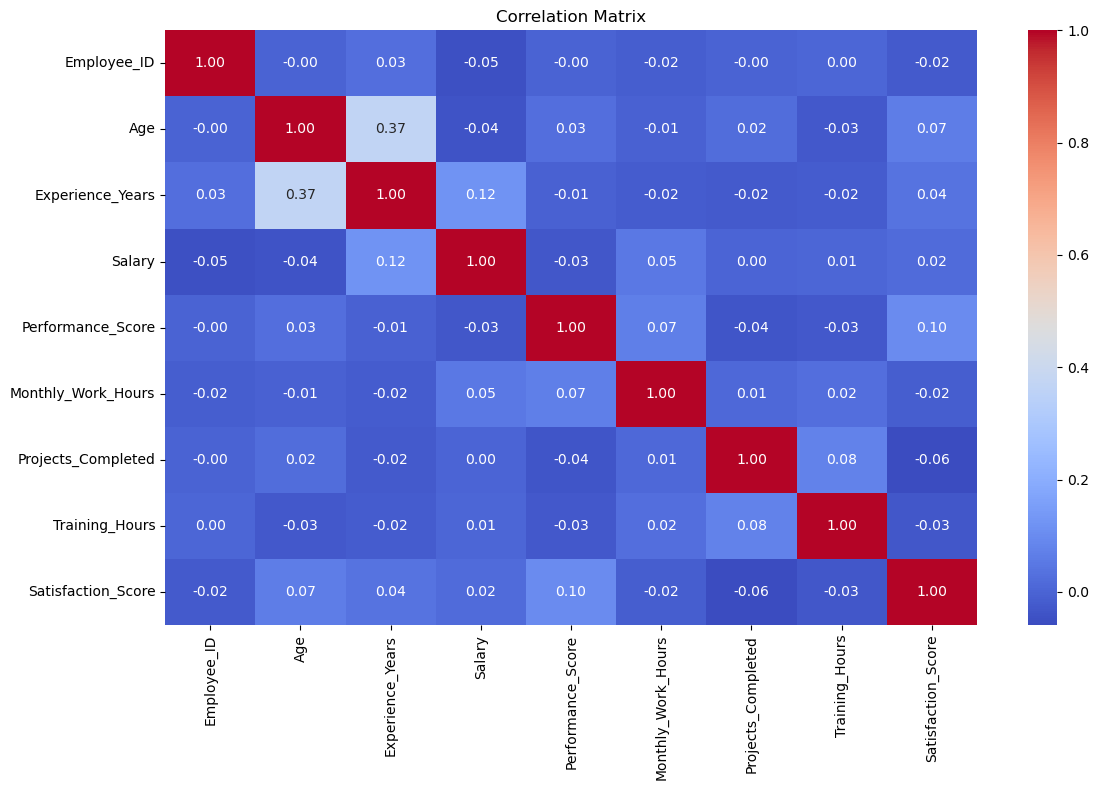

In [52]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Business Insight

The heatmap highlights the strength of relationships between numerical variables.

Values close to **1** indicate a strong positive relationship, while values close to **-1** indicate a strong negative relationship.

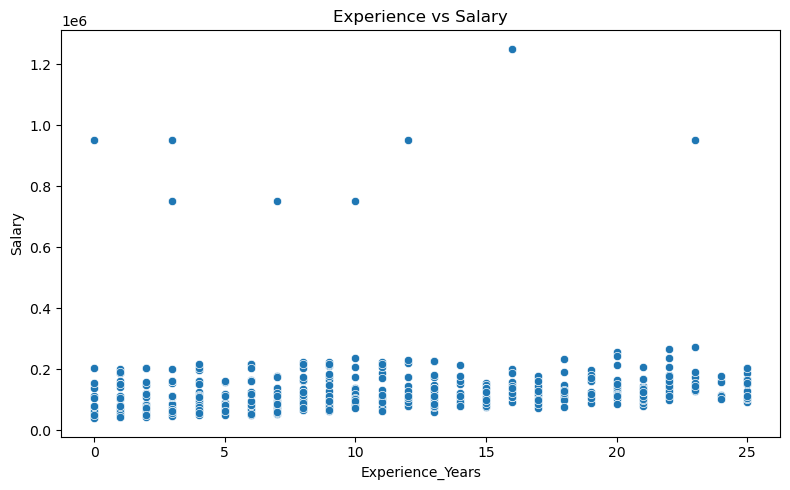

In [53]:
# Experience vs Salary

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="Experience_Years",
    y="Salary"
)

plt.title("Experience vs Salary")

plt.tight_layout()

plt.show()

### Business Insight

This visualization helps determine whether employees with more experience generally receive higher salaries.

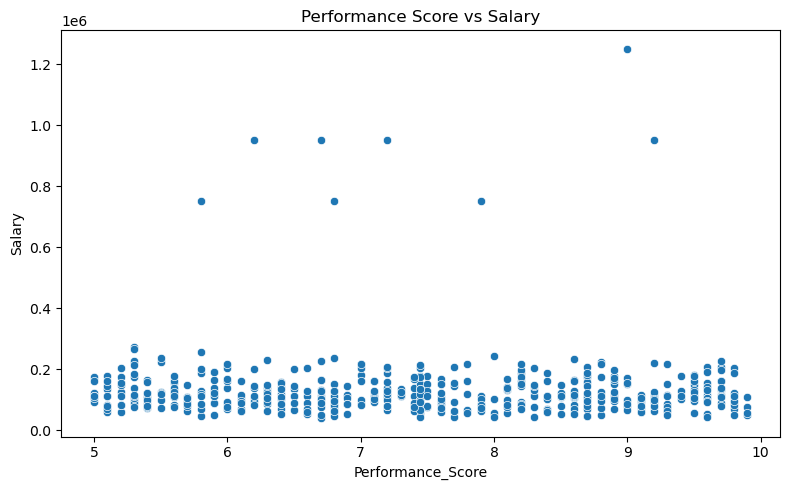

In [54]:
# Performance Score vs Salary

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="Performance_Score",
    y="Salary"
)

plt.title("Performance Score vs Salary")

plt.tight_layout()

plt.show()

### Business Insight

This plot shows whether higher-performing employees are rewarded with higher salaries.

<Axes: xlabel='Department', ylabel='Salary'>

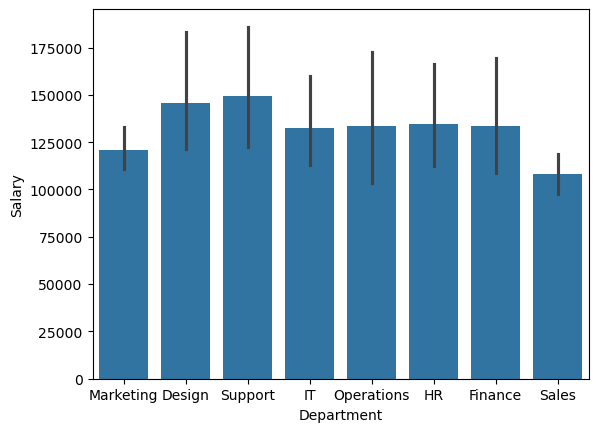

In [55]:
sns.barplot(data=clean_df, x="Department", y="Salary")

### Business Insight

The chart compares the average salary across departments and identifies departments with higher compensation.

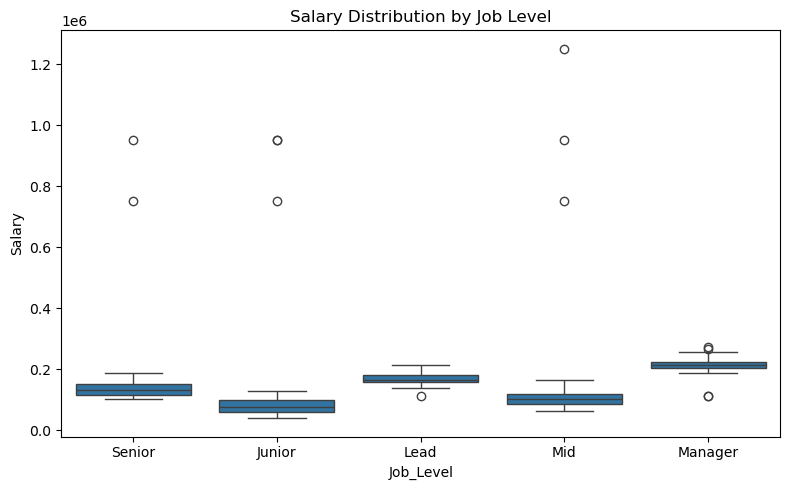

In [56]:
# Job Level vs Salary

plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="Job_Level",
    y="Salary"
)

plt.title("Salary Distribution by Job Level")

plt.tight_layout()

plt.show()

### Business Insight

Salary distribution across job levels helps identify compensation consistency and salary ranges.

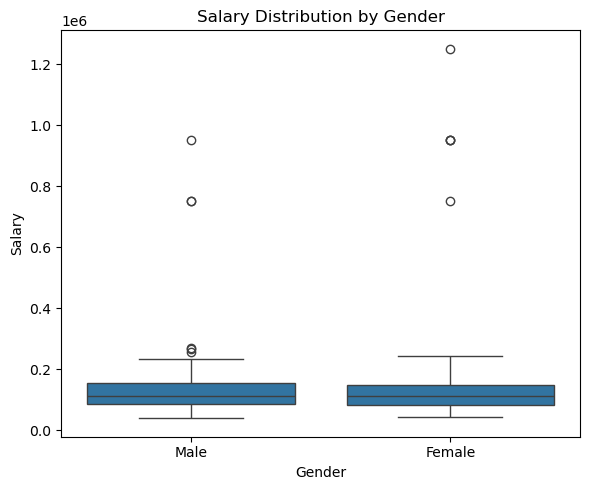

In [57]:
# Gender vs Salary

plt.figure(figsize=(6,5))

sns.boxplot(
    data=clean_df,
    x="Gender",
    y="Salary"
)

plt.title("Salary Distribution by Gender")

plt.tight_layout()

plt.show()

### Business Insight

This comparison can help identify whether salary differences exist between male and female employees.

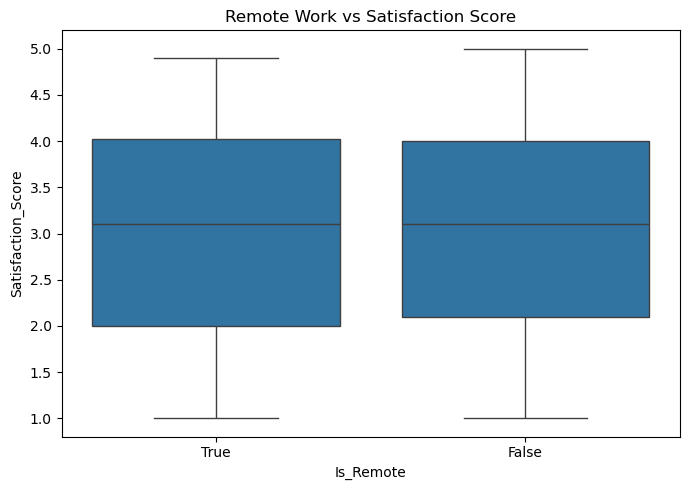

In [58]:
# Remote Work vs Satisfaction Score

plt.figure(figsize=(7,5))

sns.boxplot(
    data=clean_df,
    x="Is_Remote",
    y="Satisfaction_Score"
)

plt.title("Remote Work vs Satisfaction Score")

plt.tight_layout()

plt.show()

### Business Insight

This visualization compares employee satisfaction between remote and on-site employees.

In [59]:
# Crosstab: Department vs Attrition

department_attrition = pd.crosstab(
    clean_df["Department"],
    clean_df["Attrition"]
)

department_attrition

Attrition,No,Yes
Department,,
Design,47,8
Finance,50,19
HR,47,14
IT,61,12
Marketing,54,10
Operations,46,15
Sales,49,11
Support,51,6


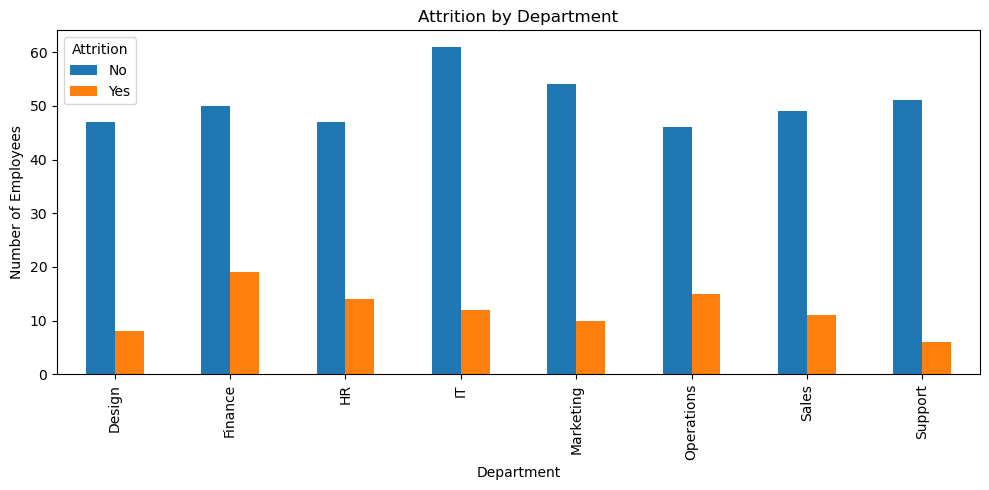

In [60]:
# Visualize Attrition by Department

department_attrition.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Attrition by Department")

plt.xlabel("Department")

plt.ylabel("Number of Employees")

plt.tight_layout()

plt.show()

### Business Insight

Departments with a higher number of employees leaving the company may require further investigation regarding workload, salary, or employee satisfaction.

In [61]:
# Average salary by Department and Gender

clean_df.groupby(
    ["Department", "Gender"]
)["Salary"].mean().round(2)

Department  Gender
Design      Female    153136.00
            Male      134722.64
Finance     Female    148527.50
            Male      115674.45
HR          Female    108937.67
            Male      150869.57
IT          Female    138298.14
            Male      119778.67
Marketing   Female    108232.57
            Male      138480.70
Operations  Female    151519.94
            Male      108749.12
Sales       Female    111935.57
            Male      104902.09
Support     Female    130844.07
            Male      168889.57
Name: Salary, dtype: float64

In [62]:
# Pivot Table

pd.pivot_table(
    clean_df,
    values="Salary",
    index="Department",
    columns="Gender",
    aggfunc="mean"
).round(2)

Gender,Female,Male
Department,,
Design,153136.00,134722.64
Finance,148527.50,115674.45
HR,108937.67,150869.57
IT,138298.14,119778.67
Marketing,108232.57,138480.70
Operations,151519.94,108749.12
Sales,111935.57,104902.09
Support,130844.07,168889.57


### Bivariate Analysis Summary

#### Key Findings

- Explored relationships between salary, experience, and performance.
- Compared salary across departments, genders, and job levels.
- Analyzed employee satisfaction based on remote work.
- Investigated department-wise attrition.

### Executive Dashboard

#### Objective

The objective of this section is to summarize the entire analysis and provide business-focused insights and recommendations for decision-makers.

In [63]:
# Total Employees
total_employees = len(clean_df)

# Total Departments
total_departments = clean_df["Department"].nunique()

# Average Salary
average_salary = clean_df["Salary"].mean()

# Average Performance Score
average_performance = clean_df["Performance_Score"].mean()

# Average Satisfaction Score
average_satisfaction = clean_df["Satisfaction_Score"].mean()

print(f"Total Employees: {total_employees}")
print(f"Departments: {total_departments}")
print(f"Average Salary: {average_salary:.2f}")
print(f"Average Performance Score: {average_performance:.2f}")
print(f"Average Satisfaction Score: {average_satisfaction:.2f}")


Total Employees: 500
Departments: 8
Average Salary: 131968.04
Average Performance Score: 7.46
Average Satisfaction Score: 3.02


#### Business Insight

The dashboard provides a quick overview of the organization and serves as a starting point for workforce analysis.

In [64]:
# Top 10 highest-paid employees
top_salary = clean_df.nlargest(10, "Salary")

top_salary[
    [
        "Name",
        "Department",
        "Job_Level",
        "Salary"
    ]
]

,Name,Department,Job_Level,Salary
362,Anam Ali,Finance,Mid,1250000.0
151,Abdullah Butt,HR,Junior,950000.0
155,Shahzaib Ahmed,Operations,Junior,950000.0
282,Umar Qureshi,Design,Mid,950000.0
436,Noor Qureshi,IT,Senior,950000.0
112,Anam Sheikh,Support,Senior,750000.0
132,Raza Qureshi,Support,Junior,750000.0
137,Maria Noor,Operations,Mid,750000.0
236,Noor Raza,Sales,Manager,270835.0
463,Shahzaib Chaudhry,Finance,Manager,267406.0


### Business Insight

Review the highest-paid employees to ensure salary structures align with experience, job level, and performance.

In [65]:
department_summary = clean_df.groupby("Department").agg({

    "Salary":"mean",

    "Performance_Score":"mean",

    "Satisfaction_Score":"mean",

    "Employee_ID":"count"

}).rename(columns={

    "Employee_ID":"Employee_Count"

}).round(2)

department_summary

,Salary,Performance_Score,Satisfaction_Score,Employee_Count
Department,,,,
Design,145770.65,7.46,2.83,55
Finance,133767.43,7.57,3.18,69
HR,134371.77,7.08,2.95,61
IT,132209.55,7.66,2.81,73
Marketing,120993.50,7.56,2.94,64
Operations,133289.75,7.16,3.25,61
Sales,108184.38,7.54,3.03,60
Support,149533.09,7.63,3.21,57


### Business Insight

Compare departments based on salary, employee performance, workforce size, and employee satisfaction.

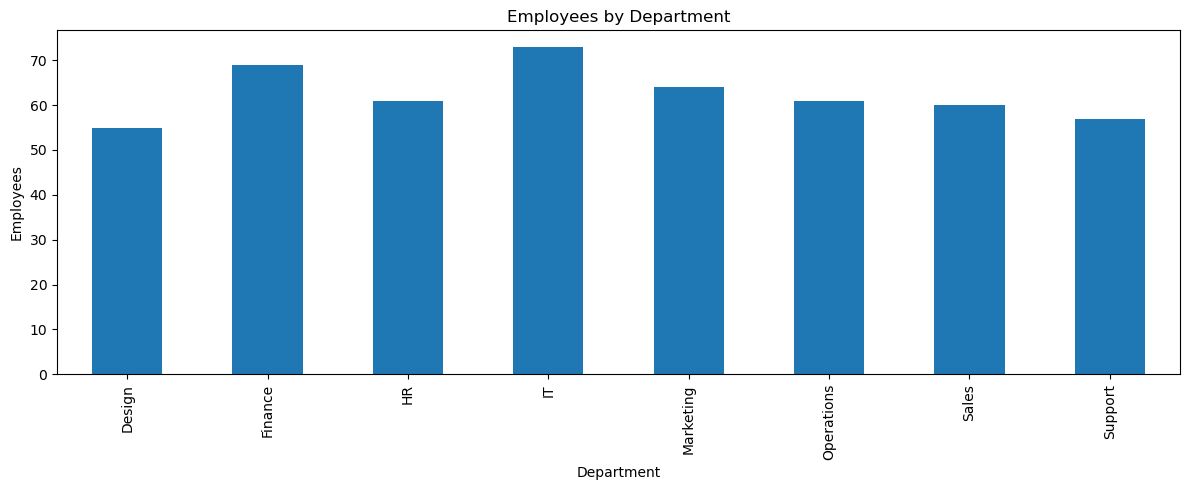

In [66]:
plt.figure(figsize=(12,5))

department_summary["Employee_Count"].plot(kind="bar")

plt.title("Employees by Department")

plt.ylabel("Employees")

plt.tight_layout()

plt.show()

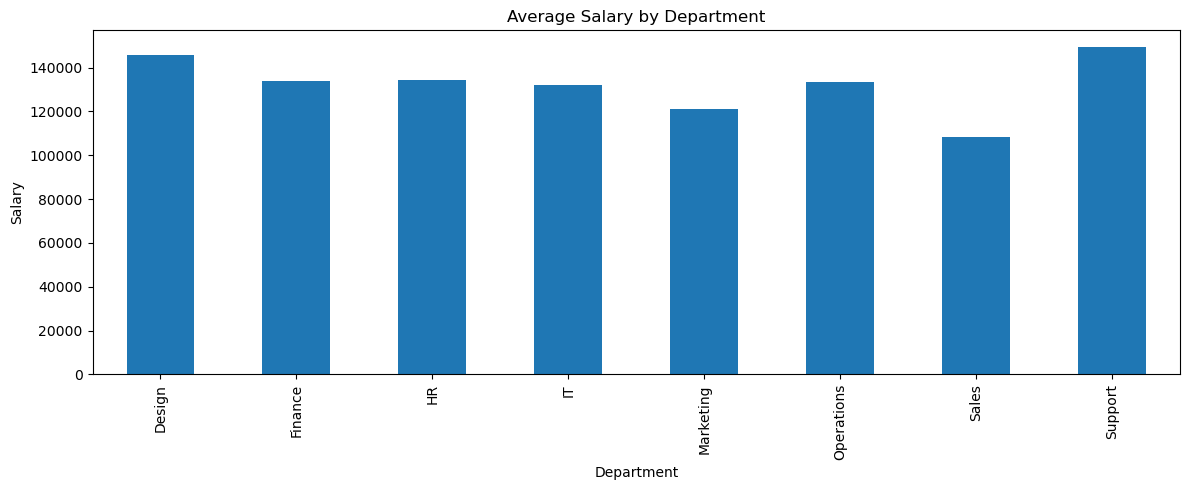

In [67]:
plt.figure(figsize=(12,5))

department_summary["Salary"].plot(kind="bar")

plt.title("Average Salary by Department")

plt.ylabel("Salary")

plt.tight_layout()

plt.show()

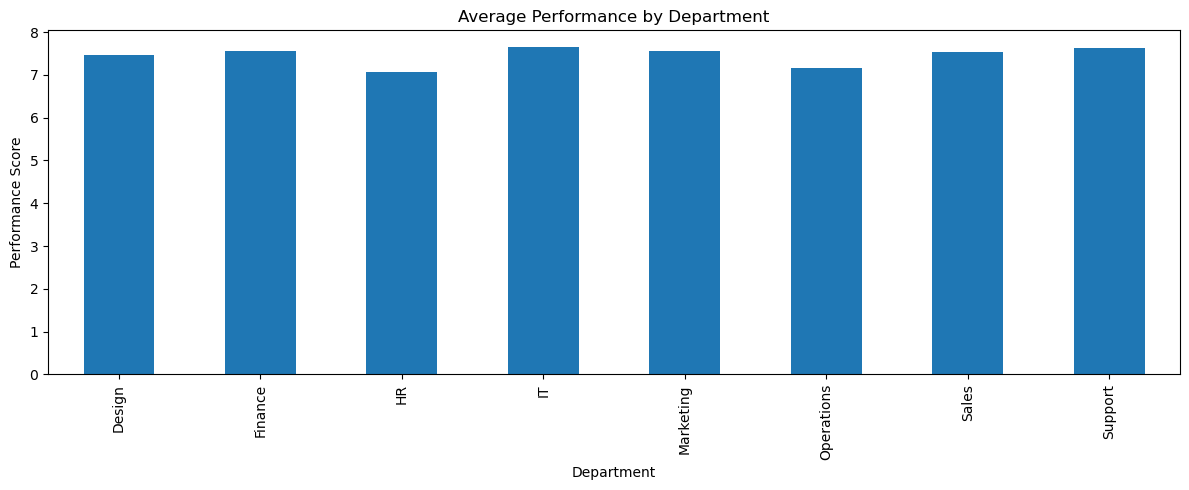

In [68]:
plt.figure(figsize=(12,5))

department_summary["Performance_Score"].plot(kind="bar")

plt.title("Average Performance by Department")

plt.ylabel("Performance Score")

plt.tight_layout()

plt.show()

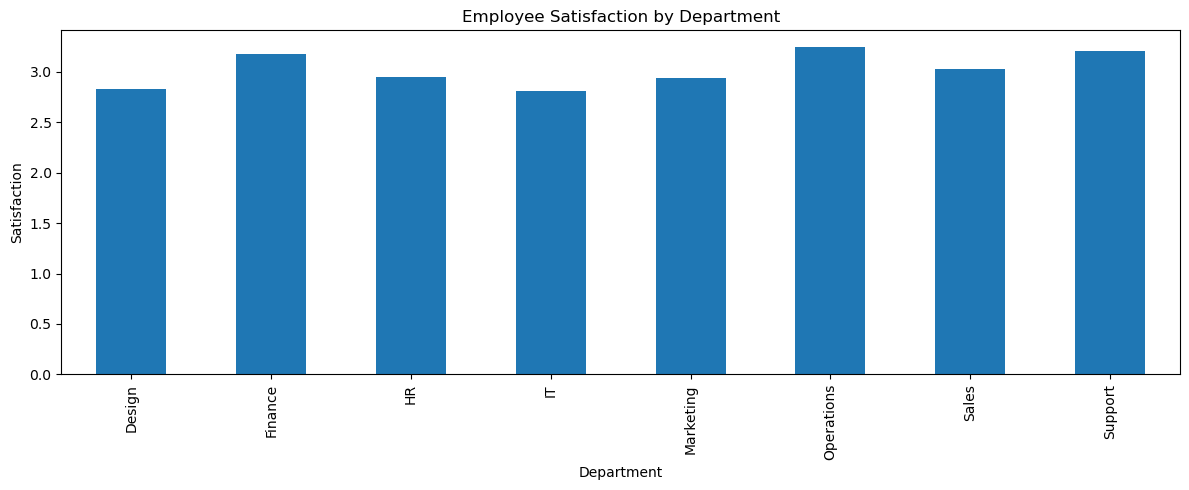

In [69]:
plt.figure(figsize=(12,5))

department_summary["Satisfaction_Score"].plot(kind="bar")

plt.title("Employee Satisfaction by Department")

plt.ylabel("Satisfaction")

plt.tight_layout()

plt.show()

#### Executive Findings

- Identify departments with the highest average salaries.
- Identify departments with the highest employee satisfaction.
- Compare department performance.
- Evaluate workforce distribution.

In [70]:
attrition_summary = clean_df["Attrition"].value_counts()

attrition_summary

Attrition
No     405
Yes     95
Name: count, dtype: int64

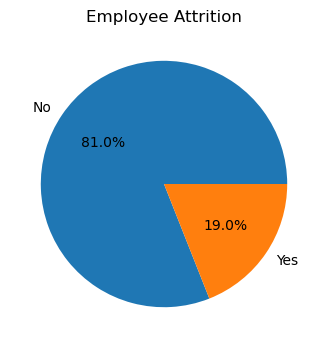

In [71]:
plt.figure(figsize=(4,4))

plt.pie(

    attrition_summary,

    labels=attrition_summary.index,

    autopct="%1.1f%%"

)

plt.title("Employee Attrition")

plt.show()

### Business Insight

A high attrition percentage may indicate employee dissatisfaction, compensation issues, or workload imbalance.

#### Final Business Recommendations

1. Standardize employee records before reporting.

2. Monitor salary fairness across departments.

3. Review departments with low satisfaction scores.

4. Investigate departments with high attrition.

5. Continue monitoring employee performance regularly.

6. Improve data quality through validation during data entry.

7. Build automated dashboards for monthly workforce monitoring.

### Project Conclusion

This project successfully completed an end-to-end Exploratory Data Analysis of employee workforce data.

The analysis included:

- Data Understanding
- Data Quality Assessment
- Data Cleaning
- Univariate Analysis
- Bivariate Analysis
- Executive Dashboard
- Business Insights
- Business Recommendations

The cleaned dataset and insights can support better workforce planning, salary decisions, employee engagement, and future machine learning projects.

In [72]:
# Save the final cleaned dataset
clean_df.to_csv(
    "../data/cleaned/final_employee_data.csv",
    index=False
)